# Task A pipeline manual validation

This notebook validates the Costa Rican electrical-grid data pipeline step by step:
loading the static ICE snapshots, parsing substations and generators, building the
weighted NetworkX national graph, assigning generators to substations, inspecting
generation-aware edge weights, extracting the `GUANACASTE_NORTH` subgrid,
visualizing it, and serializing it to the `grid_cr.json` schema.

## 1. Imports and repository path setup

The notebook lives in `notebooks/`, so it adds the repository root to `sys.path`
before importing modules from `src`.

In [1]:
import json
import math
import os
import sys
from collections import Counter
from pathlib import Path

# Required path setup when running from notebooks/.
sys.path.insert(0, os.path.abspath('..'))
repo_root = Path(os.path.abspath('..'))

# Robust fallback when the executor keeps the current working directory at repo root.
if not (repo_root / 'src').exists():
    repo_root = Path.cwd()
    sys.path.insert(0, str(repo_root))

from IPython.display import Image, display
import networkx as nx

from src import graph, ice_data, weights

print(f'Repository root: {repo_root}')
print(f'Default weight scheme: {weights.DEFAULT_SCHEME}')
print(f'Available schemes: {sorted(weights.SCHEMES)}')
assert weights.DEFAULT_SCHEME == 'generation_inverted'

Repository root: Q:\src\kraken-team-quantathon
Default weight scheme: generation_inverted
Available schemes: ['generation', 'generation_inverted', 'kv', 'kv_normalized', 'kv_over_length']


## 2. Load ICE snapshots

Load the three static GeoJSON snapshots used by the reproducible pipeline and
print their feature counts.

In [2]:
subs = ice_data.load_snapshot('substations')
lines = ice_data.load_snapshot('lines')
plants = ice_data.load_snapshot('plants')

snapshot_counts = {
    'substations': len(subs.get('features', [])),
    'lines': len(lines.get('features', [])),
    'plants': len(plants.get('features', [])),
}
print(json.dumps(snapshot_counts, indent=2, ensure_ascii=False))
assert all(count > 0 for count in snapshot_counts.values())

{
  "substations": 70,
  "lines": 102,
  "plants": 32
}


## 3. Parse generators and validate thermal classification

Parse active plants into generator records, summarize technologies, and verify the
thermal rule: `Térmico` is thermal, while `Geotérmico` is not thermal.

In [3]:
generators = graph.parse_generators(plants)
tech_counts = Counter(g['technology'] for g in generators)
thermal_counts = Counter(g['technology'] for g in generators if graph.is_thermal(g['technology']))

print(f'Active generators parsed: {len(generators)}')
print('\nCounts by technology:')
for tech, count in sorted(tech_counts.items(), key=lambda item: (str(item[0]), item[1])):
    print(f'  {tech}: {count}')

print('\nThermal counts by technology:')
for tech, count in sorted(thermal_counts.items(), key=lambda item: (str(item[0]), item[1])):
    print(f'  {tech}: {count}')

print('\nRule checks:')
print(f"  is_thermal('Térmico') = {graph.is_thermal('Térmico')}")
print(f"  is_thermal('Geotérmico') = {graph.is_thermal('Geotérmico')}")
assert graph.is_thermal('Térmico') is True
assert graph.is_thermal('Geotérmico') is False
assert all(g['thermal'] == graph.is_thermal(g['technology']) for g in generators)

Active generators parsed: 32

Counts by technology:
  Eólico: 1
  Geotérmico: 7
  Hidroeléctrico: 18
  Solar: 1
  Térmico: 5

Thermal counts by technology:
  Térmico: 5

Rule checks:
  is_thermal('Térmico') = True
  is_thermal('Geotérmico') = False


## 4. Build the national graph with generation data

Build the weighted national graph with `plants_geojson=plants`, then inspect the
node/edge counts and the build report.

In [4]:
G, report = graph.build_national_graph(subs, lines, plants_geojson=plants)
print(f'National graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(json.dumps(report, indent=2, ensure_ascii=False))
assert G.number_of_nodes() == report['n_nodes']
assert G.number_of_edges() == report['n_edges']

National graph: 75 nodes, 97 edges
{
  "unrecognized_endpoints": [
    "aguas calientes",
    "cemex",
    "changuinola",
    "frontera nicaragua",
    "progreso"
  ],
  "ignored_circuits": [
    "SIEPAC"
  ],
  "n_nodes": 75,
  "n_edges": 97
}


## 5. Inspect generator assignment

Find a substation with nearby generators and print its attached generator list,
`n_generators`, and `n_thermal` attributes.

In [5]:
preferred = ['miravalles', 'pailas']
node_with_generators = next((n for n in preferred if n in G and G.nodes[n].get('n_generators', 0) > 0), None)
if node_with_generators is None:
    node_with_generators = next(n for n, d in G.nodes(data=True) if d.get('n_generators', 0) > 0)

attrs = G.nodes[node_with_generators]
print(f'Node: {node_with_generators} ({attrs.get("name")})')
print(f"n_generators = {attrs.get('n_generators')}")
print(f"n_thermal = {attrs.get('n_thermal')}")
print(json.dumps(attrs.get('generators', []), indent=2, ensure_ascii=False))
assert attrs['n_generators'] == len(attrs['generators'])
assert attrs['n_thermal'] == sum(1 for g in attrs['generators'] if g['thermal'])

Node: miravalles (Miravalles)
n_generators = 8
n_thermal = 0
[
  {
    "plant": "Miravalles I",
    "technology": "Geotérmico",
    "thermal": false,
    "power_mw": 42.38,
    "dist_m": 117.0,
    "power_norm": 0.13840627041149578
  },
  {
    "plant": "Miravalles II",
    "technology": "Geotérmico",
    "thermal": false,
    "power_mw": 42.32,
    "dist_m": 122.0,
    "power_norm": 0.13821032005225342
  },
  {
    "plant": "Miravalles V",
    "technology": "Geotérmico",
    "thermal": false,
    "power_mw": 6,
    "dist_m": 1968.9,
    "power_norm": 0.019595035924232528
  },
  {
    "plant": "Miravalles III",
    "technology": "Geotérmico",
    "thermal": false,
    "power_mw": 27.02,
    "dist_m": 2221.7,
    "power_norm": 0.08824297844546049
  },
  {
    "plant": "Miravalles Solar",
    "technology": "Solar",
    "thermal": false,
    "power_mw": 1,
    "dist_m": 2372.6,
    "power_norm": 0.0032658393207054214
  },
  {
    "plant": "Boca Pozo",
    "technology": "Geotérmico",
    "

## 6. Inspect generation-aware edge weights

The default weight scheme is now **`generation_inverted`**: the sign-inverted
`generation` weight. The underlying generation formula makes generator-dense,
high-voltage (critical) lines *most negative*; inverting the sign makes those
critical lines score the **highest positive**, so the mostly-negative generation
weights become mostly positive. The QUBO minimizes the cut, so a critical line is
expensive to cut and the fault-zone boundary avoids it (see `docs/qubo.md`).

Base generation formula (the stored weight is its **negation**):

\[
generation = 1 - n_{gen}(u) - n_{gen}(v)
- \sum_{g} power\_norm(g)
+ 0.5 \cdot [\text{both endpoints have at least one generator}]
+ \sum_{k=1}^{T} 0.5^k
- \frac{voltage}{1000}
\qquad weight = -\,generation
\]

where `T` is the number of thermal generators across both endpoints. Thermal
means technology `Termico`; geothermal (`Geotermico`) is not thermal.
`power_norm(g)` is each generator's `power_mw` divided by the biggest generator
attached to the graph. A single originally-positive (non-critical) line can stay
slightly negative after inversion (intended).


In [6]:
def edge_components(u, v, d):
    gens_u = G.nodes[u].get('generators', [])
    gens_v = G.nodes[v].get('generators', [])
    t = G.nodes[u].get('n_thermal', 0) + G.nodes[v].get('n_thermal', 0)
    both_penalty = 0.5 if gens_u and gens_v else 0.0
    power_bonus = sum(g.get('power_norm', 0.0) for g in gens_u) \
        + sum(g.get('power_norm', 0.0) for g in gens_v)
    thermal_penalty = sum(0.5 ** k for k in range(1, t + 1))
    generation = 1 - len(gens_u) - len(gens_v) - power_bonus + both_penalty + thermal_penalty - d.get('voltage', 0) / 1000
    # Default scheme is generation_inverted: stored weight is the negation.
    expected = -generation
    return {
        'u': u,
        'v': v,
        'voltage': d.get('voltage'),
        'n_gen_u': len(gens_u),
        'n_gen_v': len(gens_v),
        'n_thermal_u': G.nodes[u].get('n_thermal', 0),
        'n_thermal_v': G.nodes[v].get('n_thermal', 0),
        'both_generator_penalty': both_penalty,
        'thermal_halving_penalty': thermal_penalty,
        'generator_power_bonus': power_bonus,
        'generation_weight': generation,
        'weight': d.get('weight'),
        'expected_inverted_weight': expected,
    }

thermal_edges = [(u, v, d) for u, v, d in G.edges(data=True)
                 if G.nodes[u].get('n_thermal', 0) + G.nodes[v].get('n_thermal', 0) > 0]
nonthermal_edges = [(u, v, d) for u, v, d in G.edges(data=True)
                    if G.nodes[u].get('n_generators', 0) + G.nodes[v].get('n_generators', 0) > 0
                    and G.nodes[u].get('n_thermal', 0) + G.nodes[v].get('n_thermal', 0) == 0]
plain_edges = [(u, v, d) for u, v, d in G.edges(data=True)
               if G.nodes[u].get('n_generators', 0) + G.nodes[v].get('n_generators', 0) == 0]

samples = []
if thermal_edges:
    samples.append(thermal_edges[0])
samples.extend(nonthermal_edges[:2])
samples.extend(plain_edges[: max(0, 3 - len(samples))])

for item in samples[:5]:
    components = edge_components(*item)
    print(json.dumps(components, indent=2, ensure_ascii=False))
    assert math.isclose(components['weight'], components['expected_inverted_weight'], rel_tol=1e-9)

# The most critical (generator-dense) line scores the highest positive weight.
gen_edges = [(u, v, d) for u, v, d in G.edges(data=True)
             if G.nodes[u].get('n_generators', 0) + G.nodes[v].get('n_generators', 0) > 0]
if gen_edges:
    heaviest = max(gen_edges, key=lambda e: e[2]['weight'])
    print('\nHeaviest (most critical) line:', heaviest[0], '-', heaviest[1],
          'weight =', round(heaviest[2]['weight'], 3))
    assert heaviest[2]['weight'] > 0


{
  "u": "moin",
  "v": "trapiche",
  "voltage": 230,
  "n_gen_u": 2,
  "n_gen_v": 1,
  "n_thermal_u": 2,
  "n_thermal_v": 0,
  "both_generator_penalty": 0.5,
  "thermal_halving_penalty": 0.75,
  "generator_power_bonus": 1.547028086218158,
  "generation_weight": -2.527028086218158,
  "weight": 2.527028086218158,
  "expected_inverted_weight": 2.527028086218158
}
{
  "u": "pailas",
  "v": "liberia",
  "voltage": 230,
  "n_gen_u": 6,
  "n_gen_v": 2,
  "n_thermal_u": 0,
  "n_thermal_v": 0,
  "both_generator_penalty": 0.5,
  "thermal_halving_penalty": 0,
  "generator_power_bonus": 0.9527106466361855,
  "generation_weight": -7.682710646636186,
  "weight": 7.682710646636186,
  "expected_inverted_weight": 7.682710646636186
}
{
  "u": "pailas",
  "v": "mogote",
  "voltage": 230,
  "n_gen_u": 6,
  "n_gen_v": 8,
  "n_thermal_u": 0,
  "n_thermal_v": 0,
  "both_generator_penalty": 0.5,
  "thermal_halving_penalty": 0,
  "generator_power_bonus": 1.3567602873938602,
  "generation_weight": -14.08676028

## 7. Extract the `GUANACASTE_NORTH` subgrid

Extract the default nine-node Guanacaste North subgrid, print its nodes, edges,
independent cycle count, and edge weights.

In [7]:
sub = graph.extract_subregion(G, nodes=graph.GUANACASTE_NORTH, max_nodes=len(graph.GUANACASTE_NORTH))
cycles = sub.number_of_edges() - sub.number_of_nodes() + nx.number_connected_components(sub)

print(f'Subgrid: {sub.number_of_nodes()} nodes, {sub.number_of_edges()} edges, {cycles} independent cycle(s)')
print('Nodes:')
for n in sorted(sub.nodes):
    print(f'  {n}')

print('\nEdges:')
for u, v, d in sorted(sub.edges(data=True)):
    print(f"  {u} -- {v}: weight={d['weight']:.3f}, voltage={d.get('voltage')}, circuit={d.get('circuit')}")

assert set(sub.nodes).issubset(set(graph.GUANACASTE_NORTH))
assert nx.is_connected(sub)

Subgrid: 9 nodes, 9 edges, 1 independent cycle(s)
Nodes:
  arenal
  canas
  corobici
  liberia
  miravalles
  mogote
  nuevo colon
  pailas
  papagayo

Edges:
  canas -- corobici: weight=9.239, voltage=230, circuit=Corobici-Canas
  canas -- liberia: weight=6.269, voltage=230, circuit=Canas-Liberia
  corobici -- arenal: weight=9.239, voltage=230, circuit=Arenal-Corobici
  liberia -- pailas: weight=7.683, voltage=230, circuit=Pailas-Liberia
  miravalles -- arenal: weight=12.673, voltage=230, circuit=Miravalles-Arenal
  miravalles -- mogote: weight=16.106, voltage=230, circuit=Miravalles-Mogote
  pailas -- mogote: weight=14.087, voltage=230, circuit=Mogote-Pailas
  papagayo -- liberia: weight=1.514, voltage=230, circuit=Liberia-Papagayo
  papagayo -- nuevo colon: weight=-0.770, voltage=230, circuit=Papagayo-Nuevo Colon


## 8. Visualize the subgrid inline

Create a validation figure with the repository visualization helper and display it
inline.

Wrote Q:\src\kraken-team-quantathon\figures\validation_subgrid.png


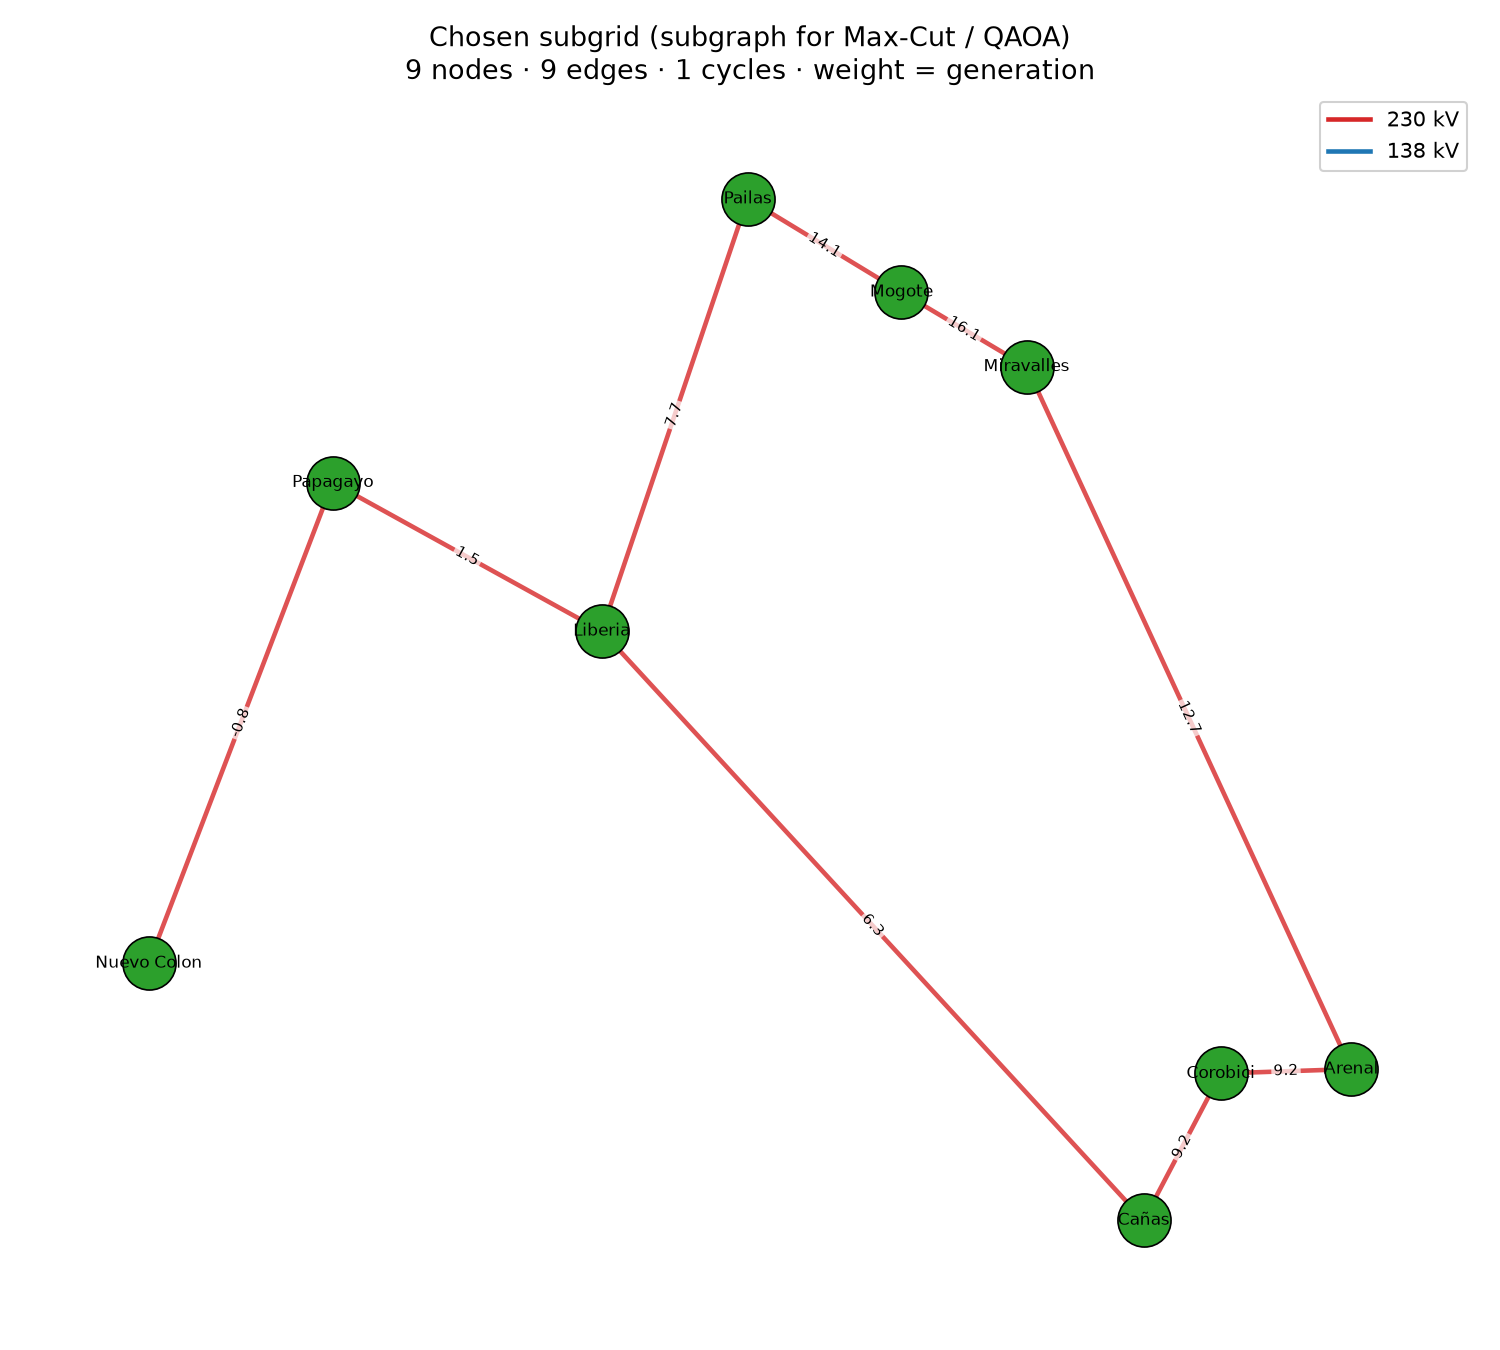

In [8]:
from src import visualize

figure_path = repo_root / 'figures' / 'validation_subgrid.png'
visualize.plot_subgraph(sub, out=figure_path)
print(f'Wrote {figure_path}')
display(Image(filename=str(figure_path)))
assert figure_path.exists()

## 9. Serialize the subgrid

Serialize with `graph.to_json`, then show one node containing generators (if the
subgrid has one) and one edge in the output schema.

In [9]:
doc = graph.to_json(sub, metadata={
    'purpose': 'manual validation notebook',
    'weight_scheme': weights.DEFAULT_SCHEME,
    'region': 'guanacaste_north',
    'independent_cycles': cycles,
})

node_example = next((node for node in doc['nodes'] if node.get('generators')), doc['nodes'][0] if doc['nodes'] else None)
edge_example = doc['edges'][0] if doc['edges'] else None

print('Top-level keys:', sorted(doc.keys()))
print('\nNode example:')
print(json.dumps(node_example, indent=2, ensure_ascii=False))
print('\nEdge example:')
print(json.dumps(edge_example, indent=2, ensure_ascii=False))

assert set(doc.keys()) == {'metadata', 'nodes', 'edges'}
assert len(doc['nodes']) == sub.number_of_nodes()
assert len(doc['edges']) == sub.number_of_edges()

Top-level keys: ['edges', 'metadata', 'nodes']

Node example:
{
  "id": "canas",
  "name": "Cañas",
  "province": "Guanacaste",
  "canton": "Cañas",
  "x": -85.1236323586436,
  "y": 10.4234985773189,
  "border": false,
  "generators": [
    {
      "plant": "Sandillal",
      "technology": "Hidroeléctrico",
      "thermal": false,
      "power_mw": 30.97,
      "dist_m": 5048.8,
      "power_norm": 0.10114304376224689
    },
    {
      "plant": "Dengo",
      "technology": "Hidroeléctrico",
      "thermal": false,
      "power_mw": 174.01,
      "dist_m": 7275.2,
      "power_norm": 0.5682887001959503
    },
    {
      "plant": "Arenal",
      "technology": "Hidroeléctrico",
      "thermal": false,
      "power_mw": 166,
      "dist_m": 14818.3,
      "power_norm": 0.5421293272371
    },
    {
      "plant": "Tejona",
      "technology": "Eólico",
      "thermal": false,
      "power_mw": 13.2,
      "dist_m": 18256.1,
      "power_norm": 0.04310907903331156
    }
  ],
  "n_generator

## 10. Build the Max-Cut QUBO (Task B)

Turn the serialized subgrid into a QUBO for Max-Cut / QAOA (`src.qubo`). Edge
weights are recomputed with the `generation_inverted` scheme (the sign-inverted
generation weight), so the mostly-negative generation weights become mostly
**positive** with the *most critical* lines scoring **highest**. The objective
then **minimizes** the total cut weight, so the fault-zone boundary avoids those
critical lines. Two quadratic penalties are added:

- **generator spread** (`0.5 * w_max` per generator-node pair): penalizes any
  two generator nodes sharing a partition, so generation ends up on both sides
  of the cut (symmetric: discourages both all-0 and all-1).
- **balance** (`0.15 * w_max`): discourages lopsided partitions.

Here `w_max` is the largest edge-weight magnitude.


In [10]:
from src import qubo

q = qubo.build_qubo(sub, weight_scheme='generation_inverted', maximize_cut=False,
                    gen_penalty_factor=0.5, balance_penalty_factor=0.15)

print('Weight scheme:', q.metadata['weight_scheme'])
print('Maximize cut:', q.metadata['maximize_cut'])
print('Variables:', q.metadata['n_variables'])
print('Generator nodes:', q.metadata['generator_nodes'])
print('Generator pairs:', q.metadata['n_generator_pairs'])
print('w_max (max |weight|):', round(q.metadata['max_edge_weight'], 3))
print('P_gen coefficient:', round(q.metadata['penalties']['generator_spread']['coefficient'], 3))
print('lambda (balance):', round(q.metadata['penalties']['balance']['coefficient'], 3))

assert q.metadata['weight_scheme'] == 'generation_inverted'
assert q.metadata['maximize_cut'] is False
assert q.metadata['n_variables'] == sub.number_of_nodes()

# generation_inverted is the exact negation of the generation weights.
plain = qubo.apply_weight_scheme(sub, 'generation')
inverted = qubo.apply_weight_scheme(sub, 'generation_inverted')
for (u, v, dp), (_, _, di) in zip(plain.edges(data=True), inverted.edges(data=True)):
    assert abs(di['weight'] + dp['weight']) < 1e-9
# Most inverted weights are positive, and the critical line scores highest.
inv_weights = [d['weight'] for _, _, d in inverted.edges(data=True)]
assert sum(w > 0 for w in inv_weights) > len(inv_weights) / 2
print('Inverted weight range: [%.3f, %.3f]' % (min(inv_weights), max(inv_weights)))


Weight scheme: generation_inverted
Maximize cut: False
Variables: 9
Generator nodes: ['arenal', 'canas', 'corobici', 'liberia', 'miravalles', 'mogote', 'pailas']
Generator pairs: 21
w_max (max |weight|): 16.106
P_gen coefficient: 8.053
lambda (balance): 2.416
Inverted weight range: [-0.770, 16.106]


### 10.1 Validate the penalties in isolation

Rebuild the QUBO with only one penalty active to confirm each behaves as
documented: the generator spread penalty is symmetric (all-generators-0 and
all-generators-1 cost the same), and the balance penalty matches
`lambda * (sum x - n/2)**2`.


In [11]:
n = q.metadata['n_variables']
w_max = q.metadata['max_edge_weight']

# Generator spread alone: symmetric penalty on the all-same states.
qg = qubo.QUBO(variables=sorted(sub.nodes), linear={}, quadratic={})
qubo.add_generator_spread_penalty(qg, sub, 0.5 * w_max)
n_pairs = q.metadata['n_generator_pairs']
all0 = qg.energy({name: 0 for name in qg.variables})
all1 = qg.energy({name: 1 for name in qg.variables})
print('generator spread  all-0:', all0, ' all-1:', all1)
target = 0.5 * w_max * n_pairs
assert abs(all0 - target) < 1e-6 and abs(all1 - target) < 1e-6

# Balance alone: matches the closed-form expansion for a couple of assignments.
qb = qubo.QUBO(variables=sorted(sub.nodes), linear={}, quadratic={})
qubo.add_balance_penalty(qb, sub, 0.15 * w_max)
import itertools
for bits in [(0,)*n, (1,)*n, (1, 0) * (n // 2) + (1,) * (n % 2)]:
    expected = 0.15 * w_max * (sum(bits) - n / 2.0) ** 2
    assert abs(qb.energy(list(bits)) - expected) < 1e-6
print('balance penalty matches (sum x - n/2)^2 expansion')


generator spread  all-0: 169.11673089484  all-1: 169.11673089484003
balance penalty matches (sum x - n/2)^2 expansion


### 10.2 Ising round-trip and serialization

Confirm the QUBO and its Ising form agree on random assignments (via
`x = (1 - z)/2`), then serialize to the `qubo_cr.json` schema.


In [12]:
import random
ising = qubo.qubo_to_ising(q)
random.seed(0)
for _ in range(200):
    bits = [random.randint(0, 1) for _ in range(n)]
    z = [1 - 2 * b for b in bits]
    e = ising['offset'] + sum(h * z[i] for i, h in enumerate(ising['h']))
    e += sum(J * z[i] * z[j] for (i, j), J in ising['J'].items())
    assert abs(e - q.energy(bits)) < 1e-6
print('QUBO <-> Ising round-trip holds on 200 random assignments')

doc = qubo.to_json(q, metadata={'purpose': 'manual validation notebook'})
print('Top-level keys:', sorted(doc.keys()))
print('QUBO linear terms:', len(doc['qubo']['linear']),
      ' quadratic terms:', len(doc['qubo']['quadratic']))
assert set(doc.keys()) == {'metadata', 'variables', 'qubo', 'ising'}
assert len(doc['variables']) == n


QUBO <-> Ising round-trip holds on 200 random assignments
Top-level keys: ['ising', 'metadata', 'qubo', 'variables']
QUBO linear terms: 9  quadratic terms: 36


## 11. Manual validation checklist

Validated in this notebook:

- Static ICE snapshots load from `data/raw/`.
- Active generation plants parse correctly.
- Thermal classification treats `Térmico` as thermal and `Geotérmico` as non-thermal.
- The national graph builds with generator assignments and the `generation` weight scheme.
- Edge weights match the documented generation formula, including the thermal halving penalty when applicable.
- The `GUANACASTE_NORTH` subgrid is connected and has an independent cycle count.
- The subgrid can be visualized and serialized to the expected JSON schema.
- The subgrid converts to a QUBO with `generation_inverted` weights (mostly positive, critical lines highest) under a minimize-cut objective.
- The generator spread penalty is symmetric and the balance penalty matches its closed form.
- The QUBO and its Ising form agree, and the QUBO serializes to the expected schema.
